### Interpretability of Random Forests for all regions.

File generated 4/20/2026

Joint Box and Whisker plots for regions/leadtimes.

In [1]:
#relevant import statements
import numpy as np
import math
import pandas as pd
import xarray as xr 
import pickle 
import matplotlib.pyplot as plt


#import seaborn as sns # statistical data visualization

##just to stop the excess number of warnings 
import warnings
warnings.filterwarnings('ignore')

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from geopy.distance import great_circle
import cartopy.crs as ccrs
from matplotlib.path import Path

In [2]:
##import files to make the plots
from PredictionPlots_BW import extrapolate
from PredictionPlots_BW import daily_anomaly

from PredictionPlots_BW import preprocess_ellipse
from PredictionPlots_BW import BWcheckevent_label

from PredictionPlots_BW import BWplot

## Plot!

Load data...
Remove leap year and shift data...
Test wind shape: (62, 135)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 129)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 119)
 
Removing NaNs ...
Returning final input array.


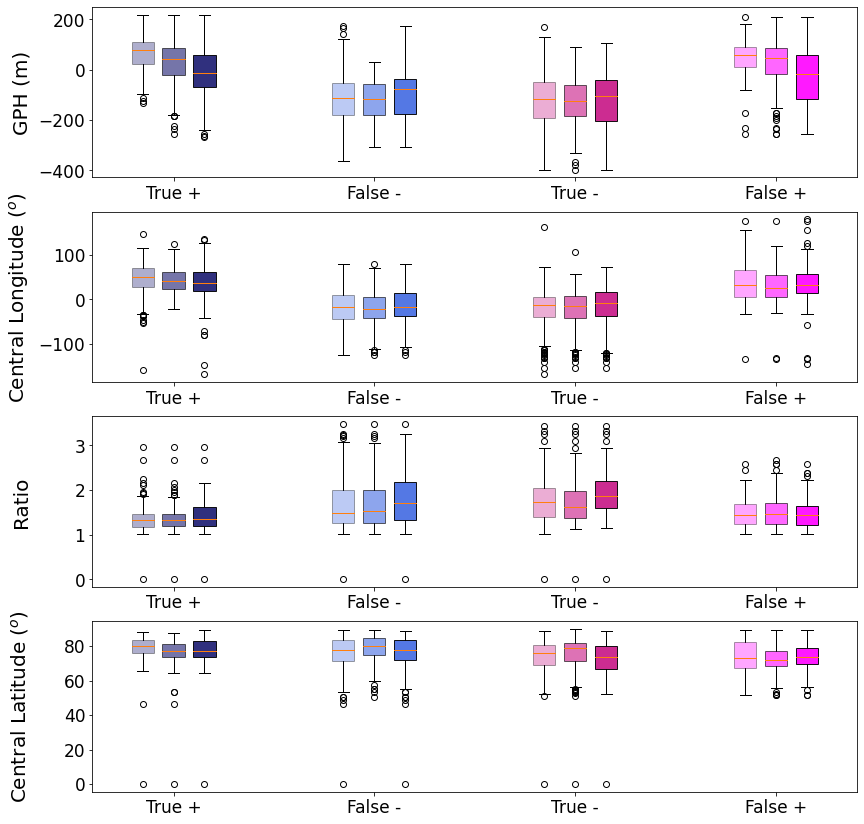

In [3]:
##Europe 
leads = [14,20,30]
idxs = [135,129,119]

#containers for all leads
Tpos_all, Tneg_all, Fpos_all, Fneg_all = [], [], [], []

for i in range(len(leads)):
    shift = leads[i]
    idx = idxs[i]
    
    input_metrics = np.empty((62,idx,8))
    input = preprocess_ellipse(input_metrics,shift,idx)

    eur_input = np.empty((62,idx,4))
    eur_metrics_list = ["GPH (m)","Central Longitude ($^o$)",
                        "Ratio","Central Latitude ($^o$)"]
    eur_input[:,:,0] = input[:,:,6]
    eur_input[:,:,1] = input[:,:,3]
    eur_input[:,:,2] = input[:,:,1]
    eur_input[:,:,3] = input[:,:,2]

    #indices
    infile = open(f"./{shift}days/index/posXtest_eur14.p", 'rb') 
    eur_pos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FposXtest_eur14.p", 'rb') 
    eur_Fpos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/negXtest_eur14.p", 'rb') 
    eur_neg = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FnegXtest_eur14.p", 'rb') 
    eur_Fneg = pickle.load(infile); infile.close()
    
    #compute
    Tpos_all.append(BWcheckevent_label(eur_pos, eur_input, idx))
    Tneg_all.append(BWcheckevent_label(eur_neg, eur_input, idx))
    Fpos_all.append(BWcheckevent_label(eur_Fpos, eur_input, idx))
    Fneg_all.append(BWcheckevent_label(eur_Fneg, eur_input, idx))

# now pass ALL leads
BWplot(Tpos_all, Tneg_all, Fpos_all, Fneg_all, eur_metrics_list, " Europe", "eurBW_ALL.png")

Load data...
Remove leap year and shift data...
Test wind shape: (62, 135)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 129)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 119)
 
Removing NaNs ...
Returning final input array.


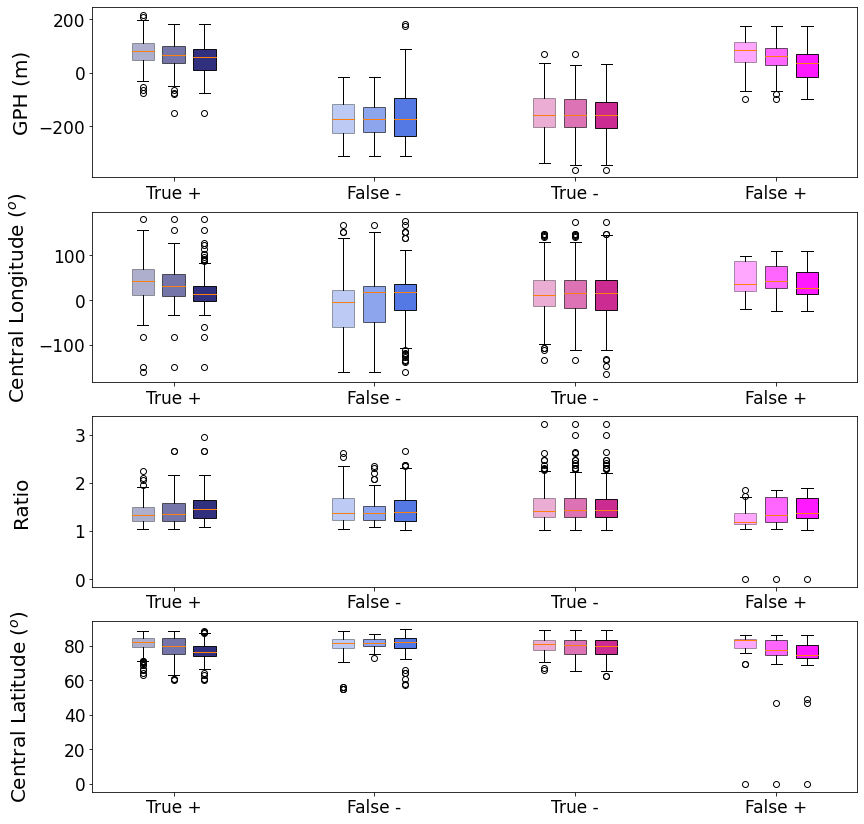

In [4]:
##Canada
leads = [14,20,30]
idxs = [135,129,119]

#containers for all leads
Tpos_all, Tneg_all, Fpos_all, Fneg_all = [], [], [], []

for i in range(len(leads)):
    shift = leads[i]
    idx = idxs[i]
    
    input_metrics = np.empty((62,idx,8))
    input = preprocess_ellipse(input_metrics,shift,idx)

    canada_input = np.empty((62,idx,4))
    canada_metrics_list = ["GPH (m)","Central Longitude ($^o$)",
                           "Ratio","Central Latitude ($^o$)"]
    
    canada_input[:,:,0] = input[:,:,6]
    canada_input[:,:,1] = input[:,:,3]
    canada_input[:,:,2] = input[:,:,1]
    canada_input[:,:,3] = input[:,:,2]

    #indices
    infile = open(f"./{shift}days/index/posXtest_can14.p", 'rb') 
    can_pos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FposXtest_can14.p", 'rb') 
    can_Fpos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/negXtest_can14.p", 'rb') 
    can_neg = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FnegXtest_can14.p", 'rb') 
    can_Fneg = pickle.load(infile); infile.close()
    
    #compute
    Tpos_all.append(BWcheckevent_label(can_pos, canada_input, idx))
    Tneg_all.append(BWcheckevent_label(can_neg, canada_input, idx))
    Fpos_all.append(BWcheckevent_label(can_Fpos, canada_input, idx))
    Fneg_all.append(BWcheckevent_label(can_Fneg, canada_input, idx))

#pass ALL leads to plotting
BWplot(Tpos_all, Tneg_all, Fpos_all, Fneg_all,
       canada_metrics_list, " Canada", "canBW_ALL.png")

Load data...
Remove leap year and shift data...
Test wind shape: (62, 135)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 129)
 
Removing NaNs ...
Returning final input array.
Load data...
Remove leap year and shift data...
Test wind shape: (62, 119)
 
Removing NaNs ...
Returning final input array.


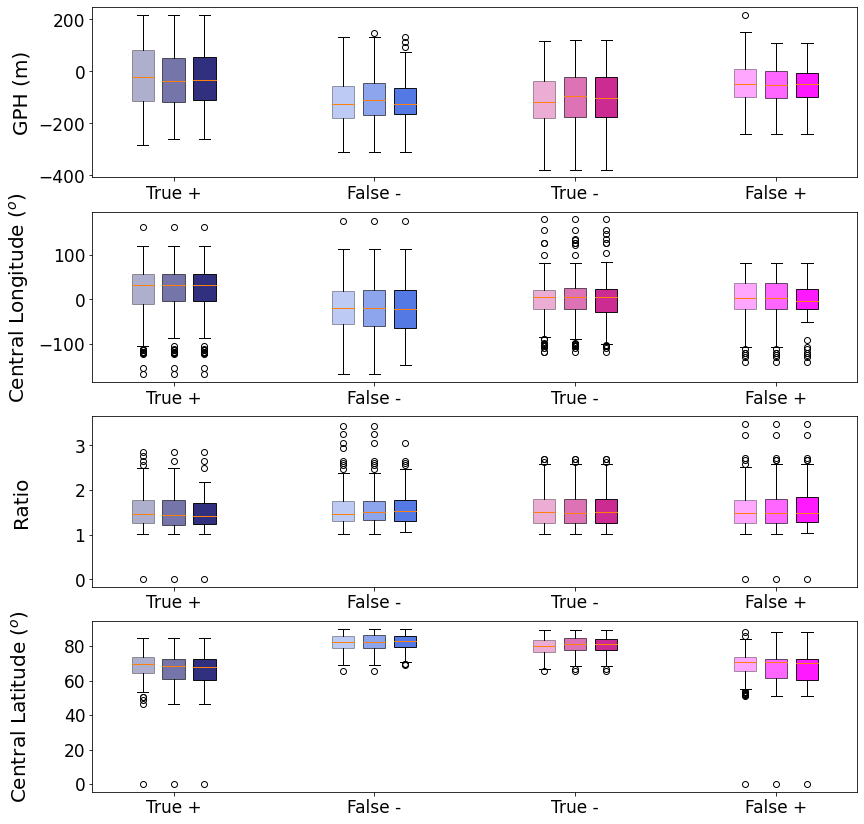

In [5]:
##SE US
leads = [14,20,30]
idxs = [135,129,119]

#containers
Tpos_all, Tneg_all, Fpos_all, Fneg_all = [], [], [], []

for i in range(len(leads)):
    shift = leads[i]
    idx = idxs[i]
    
    input_metrics = np.empty((62,idx,8))
    ellipse_input = preprocess_ellipse(input_metrics, shift, idx)
    
    seus_input = np.empty((62,idx,4))
    seus_metrics_list = ["GPH (m)","Central Longitude ($^o$)",
                         "Ratio","Central Latitude ($^o$)"]
    
    seus_input[:,:,0] = ellipse_input[:,:,6]
    seus_input[:,:,1] = ellipse_input[:,:,3]
    seus_input[:,:,2] = ellipse_input[:,:,1]
    seus_input[:,:,3] = ellipse_input[:,:,2]

    #indices
    infile = open(f"./{shift}days/index/posXtest_seu14.p", 'rb') 
    seu_pos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FposXtest_seu14.p", 'rb') 
    seu_Fpos = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/negXtest_seu14.p", 'rb') 
    seu_neg = pickle.load(infile); infile.close()
    
    infile = open(f"./{shift}days/index/FnegXtest_seu14.p", 'rb') 
    seu_Fneg = pickle.load(infile); infile.close()
    
    #compute
    Tpos_all.append(BWcheckevent_label(seu_pos, seus_input, idx))
    Tneg_all.append(BWcheckevent_label(seu_neg, seus_input, idx))
    Fpos_all.append(BWcheckevent_label(seu_Fpos, seus_input, idx))
    Fneg_all.append(BWcheckevent_label(seu_Fneg, seus_input, idx))

#plot all leads together
BWplot(Tpos_all, Tneg_all, Fpos_all, Fneg_all, seus_metrics_list, " SE US", "seuBW_ALL.png")